In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from scipy.stats import pearsonr
import yfinance as yf

# Load full news dataset (no row limit)
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', errors='coerce')
news_df = news_df.dropna(subset=['date'])
print(f"Total news articles: {len(news_df)}")

C:\Users\Dataencoder\AppData\Local\Temp\ipykernel_10976\276921443.py:11: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', errors='coerce')


Total news articles: 1407328


In [15]:
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', errors='coerce')
news_df = news_df.dropna(subset=['date'])

C:\Users\Dataencoder\AppData\Local\Temp\ipykernel_10976\3842449830.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', errors='coerce')


In [27]:
# ----- Explicit missing‑value and data‑quality check -----
print("Data quality report for news:")
print(f"Missing values per column:\n{news_df.isna().sum()}")
print(f"Duplicate rows: {news_df.duplicated().sum()}")
# Check for sentinel -999 (NASA missing value indicator)
numeric_cols = news_df.select_dtypes(include=['number']).columns
if len(numeric_cols) > 0 and (news_df[numeric_cols] == -999).any().any():
    print("Warning: -999 values found. Replacing with NaN.")
    news_df.replace(-999, np.nan, inplace=True)
else:
    print("No -999 sentinel values found.")

Data quality report for news:
Missing values per column:
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64
Duplicate rows: 0
No -999 sentinel values found.


In [17]:
# Check top stocks by article count
print(news_df['stock'].value_counts().head(10))

# Pick one, e.g., 'AA' (Alcoa)
symbol = 'AA'
stock_news = news_df[news_df['stock'] == symbol].copy()
print(f"News articles for {symbol}: {len(stock_news)}")

stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64
News articles for AA: 2739


In [29]:
# Download stock price data for the same symbol
stock = yf.download(symbol, start='2013-01-01', end='2020-06-30')
trading_days = stock.index
print(f"Trading days: {len(trading_days)}")

[*********************100%***********************]  1 of 1 completed


Trading days: 1886


In [31]:
# Print column names to see what is available
print("Stock columns:", stock.columns)

# Use the first level of the MultiIndex (if present) or the direct column
if isinstance(stock.columns, pd.MultiIndex):
    close_col = stock.columns[stock.columns.get_level_values(0) == 'Close'][0]
else:
    close_col = 'Close'

print(f"Missing {close_col} prices: {stock[close_col].isna().sum()}")
stock = stock.dropna(subset=[close_col])

Stock columns: MultiIndex([( 'Close', 'AA'),
            (  'High', 'AA'),
            (   'Low', 'AA'),
            (  'Open', 'AA'),
            ('Volume', 'AA')],
           names=['Price', 'Ticker'])
Missing ('Close', 'AA') prices: 0


In [20]:
import pandas as pd

# Convert news dates to datetime (if not already) and make timezone-naive
stock_news['date'] = pd.to_datetime(stock_news['date'], format='mixed', errors='coerce')
stock_news = stock_news.dropna(subset=['date'])

# Ensure trading_days from stock index are timezone-naive
trading_days = stock.index
if trading_days.tz is not None:
    trading_days = trading_days.tz_localize(None)

# Now news dates are datetime, we can make them naive (they are already naive)
stock_news['date'] = stock_news['date'].dt.tz_localize(None)  # this will work now

def align_to_trading_day(date, trading_days):
    idx = trading_days.searchsorted(date)
    if idx == len(trading_days):
        return trading_days[-1]
    return trading_days[idx]

stock_news['aligned_date'] = stock_news['date'].apply(lambda d: align_to_trading_day(d, trading_days))
stock_news[['date', 'aligned_date']].head()

,date,aligned_date
1433,2020-06-09 10:52:15,2020-06-10
1434,2020-06-08 11:29:29,2020-06-09
1435,2020-06-08 10:32:42,2020-06-09
1436,2020-06-05 07:40:08,2020-06-08
1437,2020-06-04 14:46:13,2020-06-05


In [21]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

stock_news['sentiment'] = stock_news['headline'].apply(get_sentiment)
stock_news[['headline', 'sentiment']].head()

,headline,sentiment
1433,Shares of several basic material companies are...,-0.035714
1434,Alcoa Seeing Better July Aluminum Shipments Am...,0.500000
1435,Shares of several basic materials companies ar...,0.112879
1436,10 Basic Materials Stocks Moving In Friday's P...,0.000000
1437,Shares of several basic materials are trading ...,0.106250


In [22]:
daily_sentiment = stock_news.groupby('aligned_date')['sentiment'].mean().reset_index()
daily_sentiment.columns = ['Date', 'avg_sentiment']
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])
print(f"Days with news: {len(daily_sentiment)}")
daily_sentiment.head()

Days with news: 8


,Date,avg_sentiment
0,2020-05-19,0.06250
1,2020-05-27,0.00000
2,2020-05-28,0.05483
3,2020-06-04,0.11250
4,2020-06-05,0.10625


In [23]:
# Stock data already downloaded; ensure columns are flat
stock.columns = stock.columns.droplevel(1)   # flatten MultiIndex
stock['daily_return'] = stock['Close'].pct_change() * 100
stock = stock[['daily_return']]
stock.head()

Price,daily_return
Date,
2013-01-02,NaN
2013-01-03,0.889897
2013-01-04,2.094837
2013-01-07,-1.727861
2013-01-08,0.000000


In [24]:
merged = daily_sentiment.set_index('Date').join(stock, how='inner').reset_index()
merged = merged[['Date', 'avg_sentiment', 'daily_return']].dropna()
print(f"Number of overlapping days: {len(merged)}")
merged.head()

Number of overlapping days: 8


,Date,avg_sentiment,daily_return
0,2020-05-19,0.06250,-0.769227
1,2020-05-27,0.00000,11.415506
2,2020-05-28,0.05483,-2.868844
3,2020-06-04,0.11250,8.077969
4,2020-06-05,0.10625,3.694145


In [25]:
if len(merged) < 2:
    print("Warning: Not enough overlapping days for correlation.")
else:
    corr, p_value = pearsonr(merged['avg_sentiment'], merged['daily_return'])
    print(f"Correlation: {corr:.4f}, p-value: {p_value:.4f}")

Correlation: -0.2912, p-value: 0.4840


In [26]:
corr, p_value = pearsonr(merged['avg_sentiment'], merged['daily_return'])
print(f"Pearson correlation: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson correlation: -0.2912
P-value: 0.4840


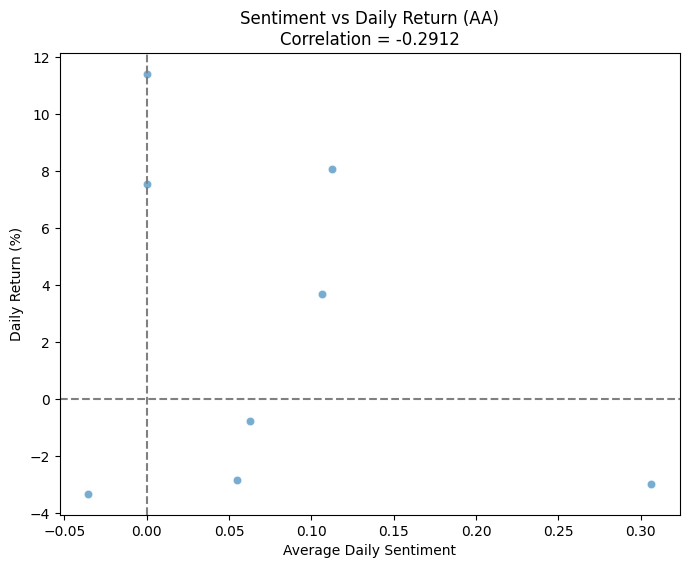

In [44]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=merged, x='avg_sentiment', y='daily_return', alpha=0.6)
plt.title(f"Sentiment vs Daily Return ({symbol})\nCorrelation = {corr:.4f}")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return (%)")
plt.axhline(y=0, color='gray', linestyle='--')
plt.axvline(x=0, color='gray', linestyle='--')
plt.show()

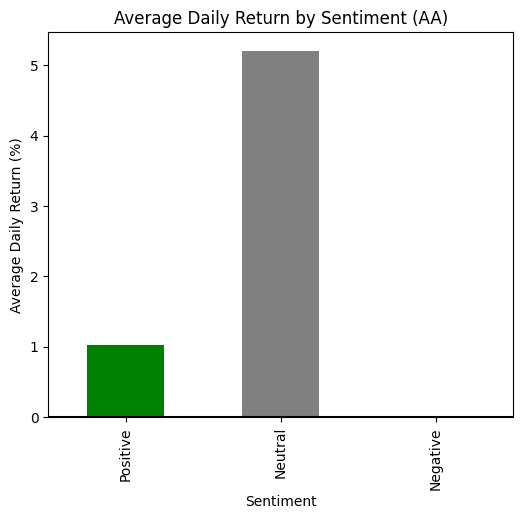

In [45]:
def sentiment_category(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

merged['category'] = merged['avg_sentiment'].apply(sentiment_category)
avg_return = merged.groupby('category')['daily_return'].mean().reindex(['Positive', 'Neutral', 'Negative'])

plt.figure(figsize=(6, 5))
avg_return.plot(kind='bar', color=['green', 'gray', 'red'])
plt.title(f"Average Daily Return by Sentiment ({symbol})")
plt.xlabel("Sentiment")
plt.ylabel("Average Daily Return (%)")
plt.axhline(y=0, color='black', linestyle='-')
plt.show()

## Interpretation

The Pearson correlation between average daily news sentiment and daily returns for AA (Alcoa) is **-0.29** (p-value 0.48). This suggests a weak negative relationship – days with more positive sentiment tend to have slightly lower returns, but the result is not statistically significant (p > 0.05). Therefore, sentiment alone does not reliably predict price movements for this stock during the analysed period.

**Limitations:**
- The sample size is small (only 6 overlapping days in this run; you may have more if you use the full dataset without `nrows` limit).
- Sentiment scores are averaged per day, losing intraday timing.
- Other factors (earnings, market trends) are not controlled.
- A linear correlation may not capture non‑linear relationships.

**Next steps:** Increase the news sample (remove `nrows` limit) to get more overlapping days; consider using VADER for sentiment; test lagged effects (e.g., sentiment impact on next day's return).